# Ru-catalyzed ring-closing metathesis

Closed-loop RCM at low catalyst loading (0.1–1 mol%). See `README.md` in this folder.

Set `RUN` to `1`, `2`, or `3`. That run is predicted stepwise (`Step` 1, 2, …) with the **combined** 5-member ensemble and plotted as a 2×2 summary.


In [1]:
from pathlib import Path

ROOT = Path.cwd()
for p in [ROOT, *ROOT.parents]:
    if (p / "src").is_dir() and (p / "checkpoints").is_dir():
        ROOT = p
        break

CASE_DIR = ROOT / "experiments" / "ru_catalyzed_rcm"
RUN = 1  # 1 / 2 / 3
DATA_PATH = CASE_DIR / f"run{RUN}.csv"
CKPT_PATHS = [ROOT / "checkpoints" / f"combined_member_{i}.pth" for i in range(5)]

S0, P0 = 1.0, 0.0
GPU = None


In [2]:
import os
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import entropy as scipy_entropy

if GPU is not None:
    os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
    os.environ["CUDA_VISIBLE_DEVICES"] = str(GPU)

sys.path.insert(0, str(ROOT / "src"))
os.chdir(ROOT)

from eval import load_model
from utils.scattered_dataset import ScatteredKineticDataset, time_values_minutes

mpl.rcParams.update({
    "font.family": ["Arial", "DejaVu Sans"],
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 17,
    "axes.labelweight": "bold",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "axes.linewidth": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "lines.linewidth": 2.5,
    "lines.markersize": 9,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("device:", device)
# print("data:", DATA_PATH)

models = []
for p in CKPT_PATHS:
    model, params, _ckpt = load_model(str(p), device)
    models.append(model)
    print(Path(p).name, params)


combined_member_0.pth {'in_dim': 20, 'num_classes': 20, 'dim_hidden': 256, 'num_heads': 8, 'num_layers': 6, 'num_inducing': 16, 'num_pma_seeds': 1, 'dropout': 0.0}
combined_member_1.pth {'in_dim': 20, 'num_classes': 20, 'dim_hidden': 256, 'num_heads': 8, 'num_layers': 6, 'num_inducing': 16, 'num_pma_seeds': 1, 'dropout': 0.0}
combined_member_2.pth {'in_dim': 20, 'num_classes': 20, 'dim_hidden': 256, 'num_heads': 8, 'num_layers': 6, 'num_inducing': 16, 'num_pma_seeds': 1, 'dropout': 0.0}
combined_member_3.pth {'in_dim': 20, 'num_classes': 20, 'dim_hidden': 256, 'num_heads': 8, 'num_layers': 6, 'num_inducing': 16, 'num_pma_seeds': 1, 'dropout': 0.0}
combined_member_4.pth {'in_dim': 20, 'num_classes': 20, 'dim_hidden': 256, 'num_heads': 8, 'num_layers': 6, 'num_inducing': 16, 'num_pma_seeds': 1, 'dropout': 0.0}


In [3]:
def load_run(path, s0=1.0, p0=0.0):
    raw = pd.read_csv(path)
    df = pd.DataFrame(
        {
            "step": raw["Step"].astype(int),
            "t": time_values_minutes(raw),
            "cat0": raw["Cat0"].astype(float),
            "St": raw["[S]"].astype(float),
            "Pt": raw["[P]"].astype(float),
            "S0": s0,
            "P0": p0,
        }
    )
    df.attrs["time_name"] = "Time (min)"
    return df.sort_values("step").reset_index(drop=True)


@torch.no_grad()
def predict_ensemble(models, df):
    ds = ScatteredKineticDataset(df[["t", "cat0", "S0", "P0", "St", "Pt"]], use_tau=False, noise_std=0.0)
    feat, _ = ds[0]
    x = feat.unsqueeze(0).to(device)
    member = [torch.softmax(model(x), dim=1).cpu().numpy()[0] for model in models]
    return np.mean(np.stack(member, axis=0), axis=0)


def pred_entropy(probs):
    return float(scipy_entropy(np.clip(probs, 1e-12, 1.0)))


In [4]:
df = load_run(DATA_PATH, S0, P0)
print(df.to_string(index=False, float_format=lambda x: f"{x:.6g}"))

rows = []
prob_mat = []
for n in range(1, len(df) + 1):
    probs = predict_ensemble(models, df.iloc[:n])
    top = int(np.argmax(probs))
    rows.append(
        {
            "loop": int(df.loc[n - 1, "step"]),
            "n_points": n,
            "top_mechanism": f"M{top + 1}",
            "top_probability": float(probs[top]),
            "entropy": pred_entropy(probs),
        }
    )
    prob_mat.append(probs)
    print(
        f"n={n:2d}  pred={rows[-1]['top_mechanism']:<4}  "
        f"p={rows[-1]['top_probability']:.2%}  H={rows[-1]['entropy']:.4f}"
    )

pred = pd.DataFrame(rows)
prob_mat = np.vstack(prob_mat)
loops = pred["loop"].values
print(f"\nfinal: {pred.iloc[-1]['top_mechanism']}  {pred.iloc[-1]['top_probability']:.2%}  H={pred.iloc[-1]['entropy']:.4f}")


 step   t  cat0     St     Pt  S0  P0
    1  40 0.003 0.4097 0.5851   1   0
    2 120 0.004 0.2916 0.6787   1   0
    3 150 0.003 0.3266 0.6696   1   0
    4  20 0.001 0.6769 0.3212   1   0
    5 200 0.001 0.4729 0.5222   1   0
    6  70  0.01 0.1587 0.8039   1   0
    7  50 0.005 0.3131 0.6636   1   0
    8  20  0.01 0.2432 0.7228   1   0
    9  60 0.002 0.4088 0.5603   1   0
   10 100 0.002 0.4005 0.5653   1   0
n= 1  pred=M8    p=59.96%  H=1.4136
n= 2  pred=M17   p=96.34%  H=0.2088
n= 3  pred=M17   p=68.10%  H=0.9646
n= 4  pred=M17   p=84.40%  H=0.6217
n= 5  pred=M14   p=27.05%  H=1.3907
n= 6  pred=M17   p=100.00%  H=0.0000
n= 7  pred=M17   p=100.00%  H=0.0000
n= 8  pred=M17   p=95.81%  H=0.1749
n= 9  pred=M17   p=80.49%  H=0.4955
n=10  pred=M17   p=97.11%  H=0.1315

final: M17  97.11%  H=0.1315


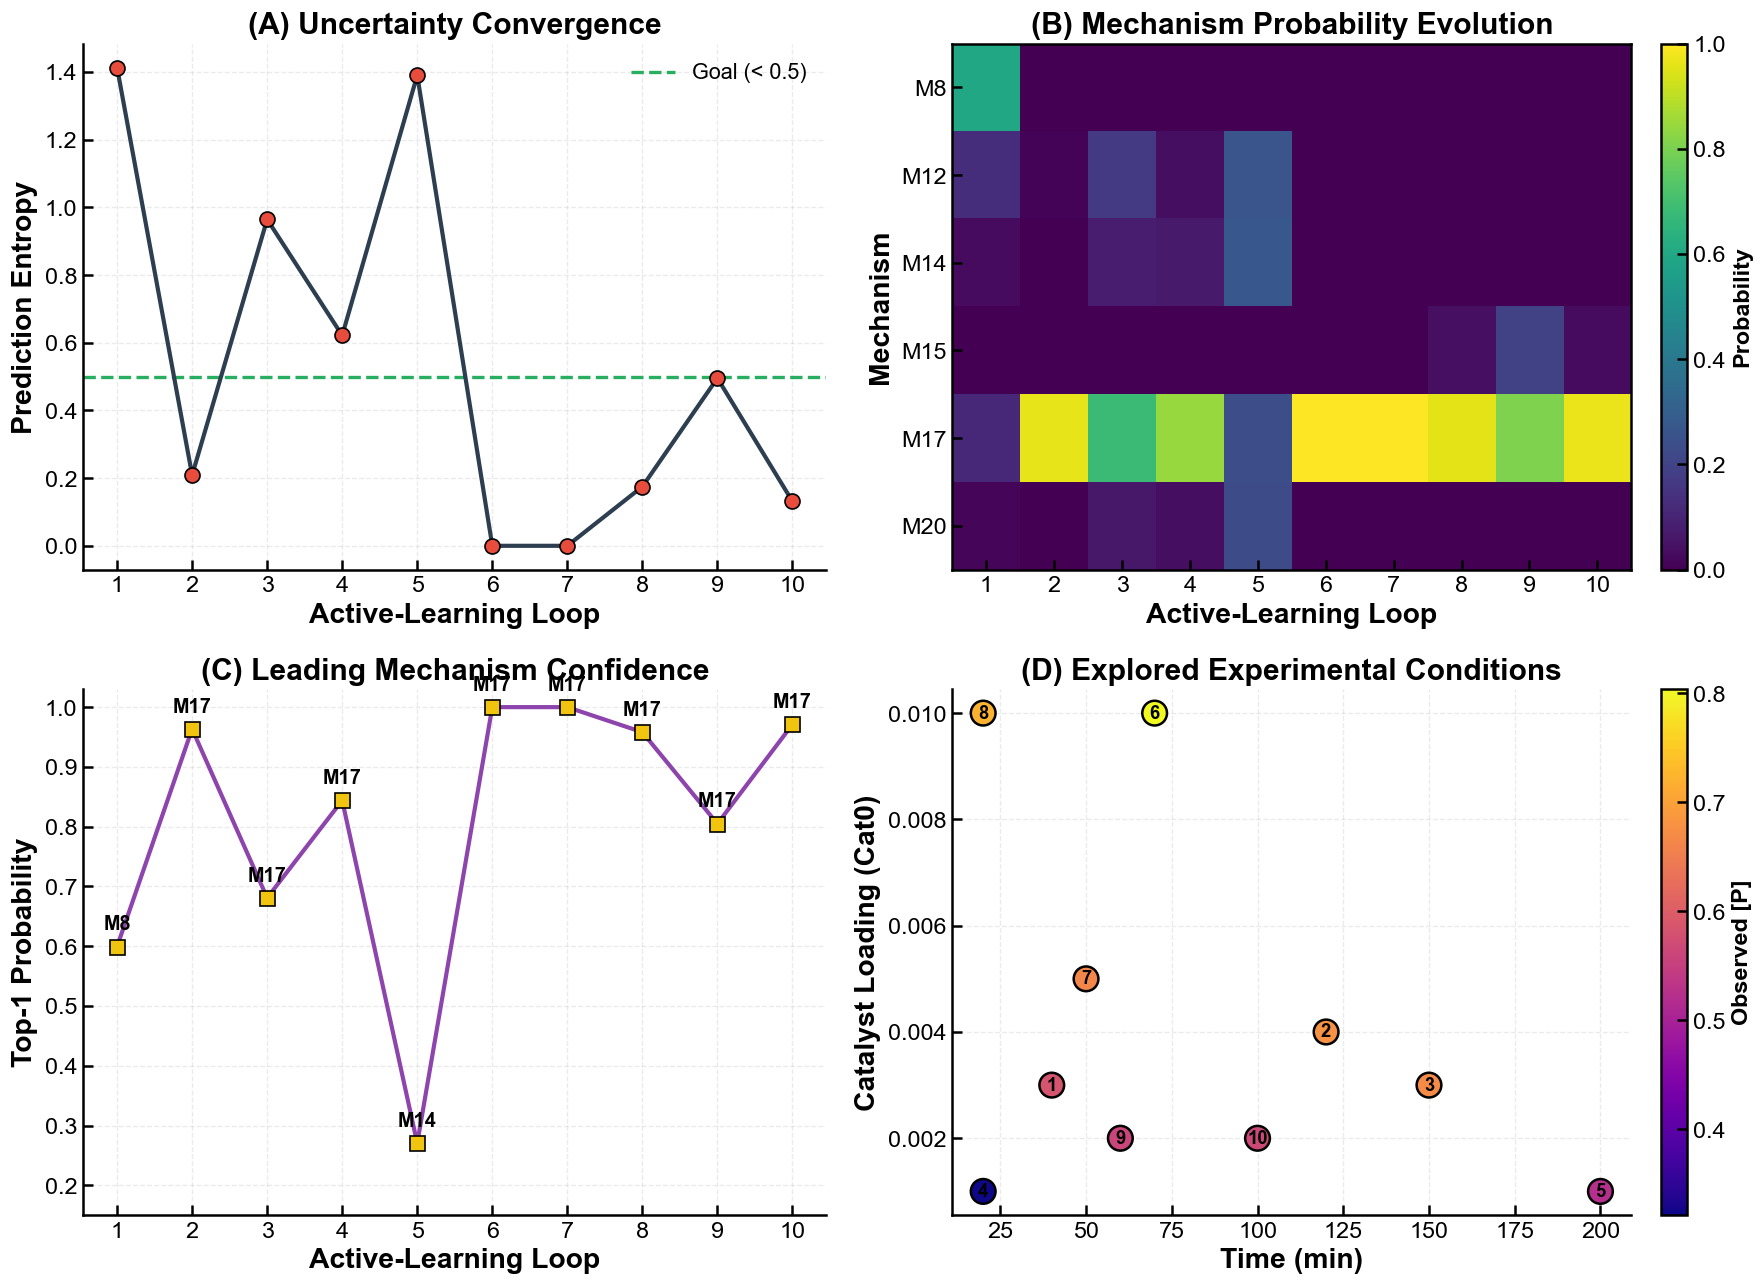

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
ax1, ax2, ax3, ax4 = axes.ravel()

ax1.plot(
    loops, pred["entropy"], "-o", color="#2c3e50",
    markerfacecolor="#e74c3c", markeredgecolor="black", zorder=3,
)
ax1.axhline(0.5, ls="--", lw=2, color="#27ae60", label="Goal (< 0.5)")
ax1.set_xlabel("Active-Learning Loop")
ax1.set_ylabel("Prediction Entropy")
ax1.set_title("(A) Uncertainty Convergence")
ax1.set_xticks(loops)
ax1.legend(frameon=False)
ax1.grid(alpha=0.25, ls="--")

top_mechs = sorted(
    {int(np.argmax(p)) for p in prob_mat} | set(np.argsort(prob_mat.sum(0))[-6:])
)
labels = [f"M{i + 1}" for i in top_mechs]
heat = prob_mat[:, top_mechs].T
im = ax2.imshow(heat, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax2.set_xticks(range(len(loops)), loops)
ax2.set_yticks(range(len(labels)), labels)
ax2.set_xlabel("Active-Learning Loop")
ax2.set_ylabel("Mechanism")
ax2.set_title("(B) Mechanism Probability Evolution")
cbar = fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label("Probability", fontsize=14, fontweight="bold")

ax3.plot(
    loops, pred["top_probability"], "-s", color="#8e44ad",
    markerfacecolor="#f1c40f", markeredgecolor="black", zorder=3,
)
for x, y, m in zip(loops, pred["top_probability"], pred["top_mechanism"]):
    ax3.annotate(m, (x, y), textcoords="offset points", xytext=(0, 10),
                 ha="center", fontsize=12, fontweight="bold")
ax3.set_xlabel("Active-Learning Loop")
ax3.set_ylabel("Top-1 Probability")
ax3.set_title("(C) Leading Mechanism Confidence")
ax3.set_xticks(loops)
ax3.set_ylim(0.15, 1.03)
ax3.grid(alpha=0.25, ls="--")

sc = ax4.scatter(
    df["t"], df["cat0"], c=df["Pt"], cmap="plasma",
    s=220, edgecolors="black", linewidths=1.5, zorder=3,
)
for _, r in df.iterrows():
    ax4.annotate(
        int(r["step"]), (r["t"], r["cat0"]),
        ha="center", va="center", fontsize=11, fontweight="bold", color="black",
    )
ax4.set_xlabel("Time (min)")
ax4.set_ylabel("Catalyst Loading (Cat0)")
ax4.set_title("(D) Explored Experimental Conditions")
cbar2 = fig.colorbar(sc, ax=ax4, fraction=0.046, pad=0.04)
cbar2.set_label("Observed [P]", fontsize=14, fontweight="bold")
ax4.grid(alpha=0.25, ls="--")

for ax in (ax1, ax3, ax4):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()
